In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [3]:
train_data = train_gen.flow_from_directory(
    'butterfly/train',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    'butterfly/valid',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    'butterfly/test',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 12639 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
Found 500 images belonging to 100 classes.


In [4]:
model = models.Sequential()

# Conv Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 4
model.add(layers.Conv2D(256, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(256, activation='relu'))

# Output Layer
model.add(layers.Dense(train_data.num_classes, activation='softmax'))

C:\Users\Shambhavee Gune\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [7]:
history = model.fit(train_data,epochs=15,validation_data=val_data)

Epoch 1/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 563s 1s/step - accuracy: 0.5044 - loss: 1.8482 - val_accuracy: 0.6360 - val_loss: 1.3606
Epoch 2/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 644s 1s/step - accuracy: 0.6948 - loss: 1.1124 - val_accuracy: 0.7440 - val_loss: 0.9539
Epoch 3/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 637s 2s/step - accuracy: 0.8041 - loss: 0.6872 - val_accuracy: 0.7820 - val_loss: 0.8934
Epoch 4/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 545s 1s/step - accuracy: 0.8827 - loss: 0.4068 - val_accuracy: 0.7720 - val_loss: 1.0202
Epoch 5/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 588s 1s/step - accuracy: 0.9242 - loss: 0.2543 - val_accuracy: 0.7680 - val_loss: 1.1469
Epoch 6/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 583s 1s/step - accuracy: 0.9524 - loss: 0.1536 - val_accuracy: 0.7720 - val_loss: 1.0723
Epoch 7/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 588s 1s/step - accuracy: 0.9517 - loss: 0.1585 - val_accuracy: 0.7720 - val_loss: 1.1760
Epoch 8/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 512s 1s/step - accuracy: 0.9712 - loss: 0.0957 - val_accu

In [8]:
loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.7783 - loss: 1.9085
Test Accuracy: 0.7620000243186951


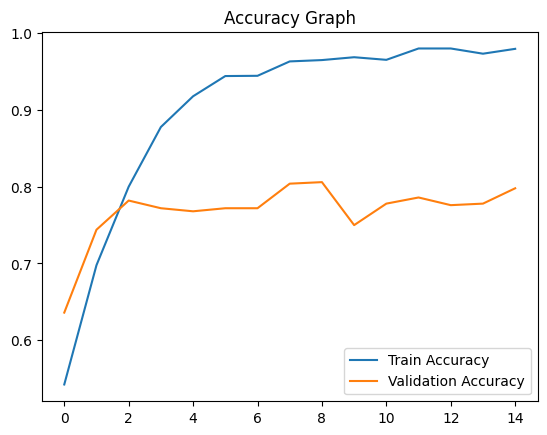

In [9]:
#acc visualization
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

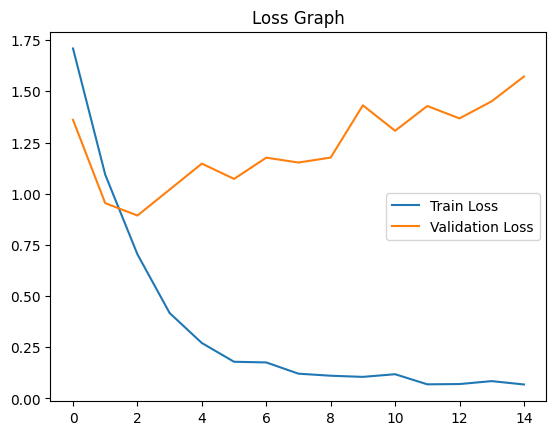

In [10]:
#loss visualization
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()